# COMP5318 Assignment 1: Rice Classification

##### Group number: 69
##### Student 1 SID: 540207680
##### Student 2 SID: 530181464

This notebook implements the required COMP5318 Assignment 1 binary classification pipeline on the Rice dataset. It follows the official assessment structure: data preprocessing, baseline evaluation in Part 1, tuned model evaluation in Part 2, and reflection in Part 3.

## Table of Contents

- [0. Install a set of used Python packages](#0-Install-a-set-of-used-Python-packages)
- [1. Data Pre-processing](#1-data-pre-processing)
- [2. Build Classifiers](#2-build-classifiers)
  - [Part 1: Cross-validation without parameter tuning](#part-1-cross-validation-without-parameter-tuning)
  - [Part 2: Cross-validation with parameter tuning](#part-2-cross-validation-with-parameter-tuning)
  - [Part 2: Results](#part-2-results)
- [3. Reflection and Discussion](#3-reflection-and-discussion)


## **0. Install a set of used Python packages**
This optional setup helper is intended for first-time local use only. Normal submission runs should not reinstall packages automatically.


In [1]:
import sys
import subprocess
import argparse
from importlib import metadata

REQUIRED_PACKAGES = [
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "scipy",
    "ipykernel",
    "Jinja2"
]


def runCommand(commandList: list[str]) -> tuple[bool, str]:
    """
    Run a command and return:
    - True/False to indicate success
    - The command output or error details
    """
    try:
        completedProcess = subprocess.run(
            commandList,
            check=True,
            text=True,
            capture_output=True
        )
        outputText = completedProcess.stdout.strip()
        if not outputText:
            outputText = completedProcess.stderr.strip()
        return True, outputText
    except subprocess.CalledProcessError as error:
        errorText = error.stderr.strip() if error.stderr else str(error)
        return False, errorText


def upgradePip(indexUrl: str | None = None) -> None:
    """
    Upgrade pip before installing the requested packages.
    """
    commandList = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "pip"
    ]

    if indexUrl:
        commandList.extend(["-i", indexUrl])

    print("Upgrading pip...")
    success, message = runCommand(commandList)

    if success:
        print("pip upgraded successfully.")
    else:
        print("pip upgrade failed, but package installation will still continue.")
        print(f"Details: {message}")


def installPackage(packageName: str, indexUrl: str | None = None) -> bool:
    """
    Install a single package with pip.

    Returns True if installation succeeds, otherwise False.
    """
    commandList = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        packageName
    ]

    if indexUrl:
        commandList.extend(["-i", indexUrl])

    print()
    print(f"Installing: {packageName}")
    success, message = runCommand(commandList)

    if success:
        print(f"Installed successfully: {packageName}")
        return True

    print(f"Failed to install: {packageName}")
    print(f"Details: {message}")
    return False


def printInstalledVersions(packageList: list[str]) -> None:
    """
    Print the installed version of each requested package.
    """
    print()
    print("Installed package versions:")
    for packageName in packageList:
        try:
            packageVersion = metadata.version(packageName)
            print(f"  {packageName}: {packageVersion}")
        except metadata.PackageNotFoundError:
            print(f"  {packageName}: not installed")


def getArguments() -> argparse.Namespace:
    """
    Parse arguments safely.

    In Jupyter Notebook, the kernel injects its own command-line arguments
    such as '-f <kernel.json>'. To avoid crashes, we ignore external args
    and use an empty argument list when running in a notebook.
    """
    parser = argparse.ArgumentParser(
        description="Install common Python packages for machine learning and data analysis."
    )
    parser.add_argument(
        "--upgrade-pip",
        action="store_true",
        help="Upgrade pip before installing packages."
    )
    parser.add_argument(
        "--index-url",
        type=str,
        default=None,
        help="Optional pip package index URL, for example a mirror."
    )

    # Notebook-safe parsing
    return parser.parse_args(args=[])


def main() -> None:
    args = getArguments()

    print("Starting package installation...")
    print(f"Python executable: {sys.executable}")
    print(f"Python version: {sys.version.split()[0]}")

    if args.upgrade_pip:
        upgradePip(args.index_url)

    successfulPackages = []
    failedPackages = []

    for packageName in REQUIRED_PACKAGES:
        if installPackage(packageName, args.index_url):
            successfulPackages.append(packageName)
        else:
            failedPackages.append(packageName)

    print()
    print("========== Installation Summary ==========")
    print(f"Successful: {len(successfulPackages)}")
    print(f"Failed: {len(failedPackages)}")

    if successfulPackages:
        print("Packages installed successfully:")
        for packageName in successfulPackages:
            print(f"  - {packageName}")

    if failedPackages:
        print("Packages that failed to install:")
        for packageName in failedPackages:
            print(f"  - {packageName}")

    printInstalledVersions(REQUIRED_PACKAGES)

    if failedPackages:
        raise RuntimeError("Some packages failed to install. Please check the output above.")

    print()
    print("All requested packages have been installed.")


# Keep installation optional so the submission notebook can run without network access.
print("Optional setup helper loaded.")
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")
printInstalledVersions(REQUIRED_PACKAGES)
print("Run main() manually only if a required package is missing in your local environment.")


Optional setup helper loaded.
Python executable: D:\ProgramData\anaconda3\python.exe
Python version: 3.12.7

Installed package versions:
  scikit-learn: 1.5.1
  pandas: 2.2.2
  numpy: 1.26.4
  matplotlib: 3.9.2
  scipy: 1.13.1
  ipykernel: 6.28.0
  Jinja2: 3.1.4
Run main() manually only if a required package is missing in your local environment.


## **1. Data Pre-processing**

In this assignment, `rice-final2.csv` is treated as a supervised binary classification dataset where the last column is the class label and all preceding columns are numeric features.
Missing values are imputed with column means using `SimpleImputer` to retain all training examples with a consistent rule.
Min-max normalization with `MinMaxScaler` maps each feature to `[0, 1]`, which supports fair comparison across classifiers that are sensitive to feature scales.
Labels are converted from `class1`/`class2` to `0`/`1` so all sklearn models and metrics can be applied consistently.
The printed first 10 rows verify that preprocessing has been applied correctly and that numeric values are reported to four decimal places.


In [2]:
# Import all libraries
from pathlib import Path
from warnings import simplefilter

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ignore future warnings
simplefilter(action='ignore', category=FutureWarning)


In [3]:
# Load the rice dataset from the assignment folder
data_path = Path("rice-final2.csv")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

riceDataFrame = pd.read_csv(data_path, na_values="?")

if riceDataFrame.shape[1] < 2:
    raise ValueError("The dataset must contain at least one feature column and one class column.")

X = riceDataFrame.iloc[:, :-1].copy()
y = riceDataFrame.iloc[:, -1].copy()

print("Dataset shape:", riceDataFrame.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Class values:", sorted(y.astype(str).str.strip().unique()))


Dataset shape: (1400, 8)
Feature matrix shape: (1400, 7)
Target vector shape: (1400,)
Class values: ['class1', 'class2']


In [4]:
# Pre-process the dataset in a reusable way so it works with other files of the same format.
def preprocess_dataset(X, y):
    """Fill missing values, normalize features, and encode class labels."""
    if X.empty:
        raise ValueError("Feature matrix is empty.")
    if y.empty:
        raise ValueError("Target vector is empty.")

    # Convert feature columns to numeric so non-numeric placeholders become NaN.
    X_numeric = X.apply(pd.to_numeric, errors="coerce")

    # Guard against columns that contain no usable values at all.
    fully_missing_cols = X_numeric.columns[X_numeric.isna().all()].tolist()
    if fully_missing_cols:
        raise ValueError(f"These feature columns contain only missing or invalid values: {fully_missing_cols}")

    # Replace missing values with the mean of each column.
    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(X_numeric)

    # Scale each feature to the [0, 1] range.
    scaler = MinMaxScaler()
    X_processed = scaler.fit_transform(X_imputed)

    # Encode class labels class1 -> 0 and class2 -> 1.
    y_clean = y.astype(str).str.strip()
    label_map = {"class1": 0, "class2": 1}
    y_processed = y_clean.map(label_map)

    if y_processed.isnull().any():
        unknown_labels = sorted(y_clean[y_processed.isnull()].unique())
        raise ValueError(f"Unexpected class labels found: {unknown_labels}")

    return X_processed, y_processed.astype(int).to_numpy(), imputer, scaler

XProcessed, yProcessed, imputer, scaler = preprocess_dataset(X, y)

# Keep a numeric feature matrix for model evaluation; fitted preprocessing stays inside pipelines later.
XModeling = X.apply(pd.to_numeric, errors="coerce")
fullyMissingModelCols = XModeling.columns[XModeling.isna().all()].tolist()
if fullyMissingModelCols:
    raise ValueError(f"These feature columns contain only missing or invalid values: {fullyMissingModelCols}")


In [5]:
# Print the first ten rows of the pre-processed dataset using four decimal places.
def print_data(X, y, n_rows=10):
    """Print the first n_rows of a numpy feature matrix and label vector."""
    if len(X) != len(y):
        raise ValueError("Feature matrix and target vector must have the same number of rows.")

    rows_to_print = min(n_rows, len(X))
    for example_num in range(rows_to_print):
        feature_text = ",".join(f"{feature:.4f}" for feature in X[example_num])
        print(f"{feature_text},{int(y[example_num])}")

print_data(XProcessed, yProcessed)


0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


In [6]:
# Display the first ten rows as a formatted table for a cleaner notebook preview.
def preview_data_table(X, y, feature_names, n_rows=10):
    """Display the first n_rows as a styled table without changing the preprocessing logic."""
    if len(X) != len(y):
        raise ValueError("Feature matrix and target vector must have the same number of rows.")
    if len(feature_names) != X.shape[1]:
        raise ValueError("feature_names must match the number of feature columns.")

    rows_to_show = min(n_rows, len(X))
    feature_cols = [str(name) for name in feature_names]
    preview_df = pd.DataFrame(X[:rows_to_show], columns=feature_cols)
    preview_df["Class"] = y[:rows_to_show].astype(int)

    styled = (
        preview_df.style
        .format({col: "{:.4f}" for col in feature_cols})
        .set_caption("Pre-processed Dataset Preview")
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "600"), ("color", "#111827")]},
            {"selector": "th", "props": [("background-color", "#1f2937"), ("color", "white"), ("text-align", "center"), ("padding", "8px 10px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "8px 10px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("border", "1px solid #d1d5db"), ("border-radius", "8px"), ("overflow", "hidden")]},
        ])
    )
    display(styled)

preview_data_table(XProcessed, yProcessed, X.columns)


,Area,Perimiter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,0.4628,0.5406,0.5113,0.4803,0.7380,0.4699,0.1196,1
1,0.4900,0.5547,0.5266,0.5018,0.7319,0.4926,0.8030,1
2,0.6109,0.6847,0.6707,0.5409,0.8032,0.6253,0.1185,0
3,0.6466,0.6930,0.6677,0.5961,0.7601,0.6467,0.2669,0
4,0.6712,0.6233,0.4755,0.8293,0.3721,0.6803,0.4211,1
5,0.2634,0.2932,0.2414,0.4127,0.5521,0.2752,0.2825,1
6,0.8175,0.9501,0.9515,0.5925,0.9245,0.8162,0.0000,0
7,0.3174,0.3588,0.3601,0.3908,0.6921,0.3261,0.8510,1
8,0.3130,0.3050,0.2150,0.5189,0.3974,0.3159,0.4570,1
9,0.5120,0.5237,0.4409,0.6235,0.5460,0.5111,0.3155,1


## **2. Build Classifiers**

This section evaluates the required classifiers in two stages:
- Part 1: Logistic Regression and Naive Bayes
- Part 2: KNN, Decision Tree, AdaBoost, Gradient Boosting, Random Forest, and SVM


### Part 1: Cross-validation without parameter tuning

Logistic Regression and Gaussian Naive Bayes are evaluated first as baseline classifiers.
Both models use stratified 10-fold cross-validation with `StratifiedKFold(n_splits=10, shuffle=True, random_state=0)` and no hyperparameter tuning, so the comparison is controlled and directly comparable.


In [7]:
# Configure 10-fold stratified cross-validation for consistent class proportions in each fold.
cvKFold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)


def make_model_pipeline(model):
    """Build a preprocessing + model pipeline for fair evaluation."""
    # Fit preprocessing inside each training fold / split to avoid preprocessing leakage.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])


In [8]:
# Logistic Regression

logRModel = LogisticRegression(
    max_iter=1000,
    random_state=0
)

logRPipeline = make_model_pipeline(logRModel)

logRScores = cross_val_score(
    estimator=logRPipeline,
    X=XModeling,
    y=yProcessed,
    cv=cvKFold,
    scoring="accuracy"
)

logRAvgAccuracy = logRScores.mean()


In [9]:
# Naive Bayes
nbModel = GaussianNB()

nbPipeline = make_model_pipeline(nbModel)

nbScores = cross_val_score(
    estimator=nbPipeline,
    X=XModeling,
    y=yProcessed,
    cv=cvKFold,
    scoring="accuracy"
)

nbAvgAccuracy = nbScores.mean()


### Part 1 Results

The following output reports the average stratified 10-fold cross-validation accuracy for each baseline classifier.


In [10]:
# Print results for each classifier in part 1 to 4 decimal places here:
print(f"LogR average cross-validation accuracy: {logRAvgAccuracy:.4f}")
print(f"NB average cross-validation accuracy: {nbAvgAccuracy:.4f}")

LogR average cross-validation accuracy: 0.9386
NB average cross-validation accuracy: 0.9264


The Part 1 results indicate that both baseline models perform strongly on the preprocessed Rice data, with Logistic Regression slightly outperforming Naive Bayes in average cross-validation accuracy. This provides a reliable baseline before introducing hyperparameter tuning in Part 2.


### Part 2: Cross-validation with parameter tuning

The remaining classifiers are tuned using `GridSearchCV` with the same stratified 10-fold splitter (`cvKFold`).
A stratified `train_test_split(..., random_state=0)` is used to create a consistent held-out test set for fair comparison of tuned models.


In [11]:
# Split the numeric feature matrix first so preprocessing can be fitted only on the training data in each pipeline.
xTrain, xTest, yTrain, yTest = train_test_split(
    XModeling,
    yProcessed,
    test_size=0.2,
    stratify=yProcessed,
    random_state=0
)


#### KNN

KNN predicts a sample from the labels of nearby training points. Tuning `n_neighbors` and distance metric parameter `p` controls locality and distance sensitivity.

Reported best parameters in this run: `n_neighbors=7`, `p=2`.


In [12]:
# KNN
# parameters you may consider
k = [1, 3, 5, 7]
p = [1, 2]

# p=1 -> Manhattan distance
# p=2 -> Euclidean distance
knnParameterGrid = {
    "model__n_neighbors": k,
    "model__p": p
}

knnModel = KNeighborsClassifier(metric="minkowski")
knnPipeline = make_model_pipeline(knnModel)

knnGridSearch = GridSearchCV(
    estimator=knnPipeline,
    param_grid=knnParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

knnGridSearch.fit(xTrain, yTrain)

knnBestModel = knnGridSearch.best_estimator_
knnBestK = knnGridSearch.best_params_["model__n_neighbors"]
knnBestP = knnGridSearch.best_params_["model__p"]
knnBestCvAccuracy = knnGridSearch.best_score_

knnTestPrediction = knnBestModel.predict(xTest)
knnTestAccuracy = accuracy_score(yTest, knnTestPrediction)


#### Decision Tree

Decision Trees learn feature-based split rules that are easy to interpret. The grid over depth and split/leaf constraints helps balance expressiveness and overfitting risk.

Reported best parameters in this run: `max_depth=3`, `min_samples_split=2`, `min_samples_leaf=1`.


In [13]:
# Decision Tree
# parameters you may consider
max_depth = [3, 5, 7, 10]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

decisionTreeParameterGrid = {
    "model__max_depth": max_depth,
    "model__min_samples_split": min_samples_split,
    "model__min_samples_leaf": min_samples_leaf
}

decisionTreeModel = DecisionTreeClassifier(random_state=0)
decisionTreePipeline = make_model_pipeline(decisionTreeModel)

decisionTreeGridSearch = GridSearchCV(
    estimator=decisionTreePipeline,
    param_grid=decisionTreeParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

decisionTreeGridSearch.fit(xTrain, yTrain)

decisionTreeBestModel = decisionTreeGridSearch.best_estimator_
decisionTreeBestMaxDepth = decisionTreeGridSearch.best_params_["model__max_depth"]
decisionTreeBestMinSamplesSplit = decisionTreeGridSearch.best_params_["model__min_samples_split"]
decisionTreeBestMinSamplesLeaf = decisionTreeGridSearch.best_params_["model__min_samples_leaf"]
decisionTreeBestCvAccuracy = decisionTreeGridSearch.best_score_

decisionTreeTestPrediction = decisionTreeBestModel.predict(xTest)
decisionTreeTestAccuracy = accuracy_score(yTest, decisionTreeTestPrediction)


#### AdaBoost

AdaBoost combines many weak learners by focusing subsequent learners on harder examples. Tuning `n_estimators` and `learning_rate` controls ensemble strength and update size.

Reported best parameters in this run: `n_estimators=100`, `learning_rate=0.1000`.


In [14]:
# Ada Boost
# parameters you may consider
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.2, 0.3, 0.5]

adaBoostParameterGrid = {
    "model__n_estimators": n_estimators,
    "model__learning_rate": learning_rate
}

adaBoostModel = AdaBoostClassifier(random_state=0)
adaBoostPipeline = make_model_pipeline(adaBoostModel)

adaBoostGridSearch = GridSearchCV(
    estimator=adaBoostPipeline,
    param_grid=adaBoostParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

adaBoostGridSearch.fit(xTrain, yTrain)

adaBoostBestNEstimators = adaBoostGridSearch.best_params_["model__n_estimators"]
adaBoostBestLearningRate = adaBoostGridSearch.best_params_["model__learning_rate"]
adaBoostBestCvAccuracy = adaBoostGridSearch.best_score_

adaBoostTestPrediction = adaBoostGridSearch.best_estimator_.predict(xTest)
adaBoostTestAccuracy = accuracy_score(yTest, adaBoostTestPrediction)


#### Gradient Boosting

Gradient Boosting fits trees sequentially to reduce residual errors. Tuning tree depth, ensemble size, and learning rate manages the bias-variance trade-off.

Reported best parameters in this run: `max_depth=1`, `n_estimators=50`, `learning_rate=0.1000`.


In [15]:
# Gradient Boost
# parameters you may consider
max_depth = [1, 3, 5, 7]
n_estimators = [50, 100, 150]
learning_rate = [0.1, 0.2, 0.3, 0.5]

gradientBoostParameterGrid = {
    "model__max_depth": max_depth,
    "model__n_estimators": n_estimators,
    "model__learning_rate": learning_rate
}

gradientBoostModel = GradientBoostingClassifier(random_state=0)
gradientBoostPipeline = make_model_pipeline(gradientBoostModel)

gradientBoostGridSearch = GridSearchCV(
    estimator=gradientBoostPipeline,
    param_grid=gradientBoostParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

gradientBoostGridSearch.fit(xTrain, yTrain)

gradientBoostBestMaxDepth = gradientBoostGridSearch.best_params_["model__max_depth"]
gradientBoostBestNEstimators = gradientBoostGridSearch.best_params_["model__n_estimators"]
gradientBoostBestLearningRate = gradientBoostGridSearch.best_params_["model__learning_rate"]
gradientBoostBestCvAccuracy = gradientBoostGridSearch.best_score_

gradientBoostTestPrediction = gradientBoostGridSearch.best_estimator_.predict(xTest)
gradientBoostTestAccuracy = accuracy_score(yTest, gradientBoostTestPrediction)


#### Random Forest

Random Forest aggregates many randomized trees to improve robustness. Following the assignment, entropy and `max_features='sqrt'` are used, while grid search tunes ensemble size and `max_leaf_nodes`.

Reported best parameters in this run: `n_estimators=30`, `max_leaf_nodes=6`.


In [16]:
# Random Forest
# You should use RandomForestClassifier from sklearn.ensemble with information gain and max_features set to 'sqrt'.
# parameters you may consider
n_estimators = [10, 30, 60, 100]
max_leaf_nodes = [6, 12]

randomForestParameterGrid = {
    "model__n_estimators": n_estimators,
    "model__max_leaf_nodes": max_leaf_nodes
}

randomForestModel = RandomForestClassifier(
    criterion="entropy",      # information gain
    max_features="sqrt",
    random_state=0
)
randomForestPipeline = make_model_pipeline(randomForestModel)

randomForestGridSearch = GridSearchCV(
    estimator=randomForestPipeline,
    param_grid=randomForestParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

randomForestGridSearch.fit(xTrain, yTrain)

randomForestBestNEstimators = randomForestGridSearch.best_params_["model__n_estimators"]
randomForestBestMaxLeafNodes = randomForestGridSearch.best_params_["model__max_leaf_nodes"]
randomForestBestCvAccuracy = randomForestGridSearch.best_score_

randomForestTestPrediction = randomForestGridSearch.best_estimator_.predict(xTest)
randomForestTestAccuracy = accuracy_score(yTest, randomForestTestPrediction)
randomForestMacroF1 = f1_score(yTest, randomForestTestPrediction, average="macro")
randomForestWeightedF1 = f1_score(yTest, randomForestTestPrediction, average="weighted")


#### SVM

SVM with an RBF kernel models nonlinear decision boundaries in transformed feature space. Tuning `C` and `gamma` controls margin flexibility and kernel influence.

Reported best parameters in this run: `C=5`, `gamma=1.0000`, `kernel=rbf`.


In [17]:
# SVM
# parameters you may consider
C = [0.01, 0.1, 1, 5]
gamma = [0.01, 0.1, 1, 10]

# optional
kernel = ["rbf"]

svmParameterGrid = {
    "model__C": C,
    "model__gamma": gamma,
    "model__kernel": kernel
}

svmModel = SVC(random_state=0)
svmPipeline = make_model_pipeline(svmModel)

svmGridSearch = GridSearchCV(
    estimator=svmPipeline,
    param_grid=svmParameterGrid,
    cv=cvKFold,
    scoring="accuracy",
    n_jobs=1
)

svmGridSearch.fit(xTrain, yTrain)

svmBestC = svmGridSearch.best_params_["model__C"]
svmBestGamma = svmGridSearch.best_params_["model__gamma"]
svmBestKernel = svmGridSearch.best_params_["model__kernel"]
svmBestCvAccuracy = svmGridSearch.best_score_

svmTestPrediction = svmGridSearch.best_estimator_.predict(xTest)
svmTestAccuracy = accuracy_score(yTest, svmTestPrediction)


### Part 2: Results

The following output reports the best hyperparameters, cross-validation accuracy, and held-out test accuracy for each tuned classifier (with Random Forest macro/weighted F1 scores as required).


In [18]:
# Report tuned-model results with assignment-required formatting:
# - floating-point metrics to 4 decimal places
# - integer-valued hyperparameters as integers
print(f"KNN best k: {knnBestK}")
print(f"KNN best p: {knnBestP}")
print(f"KNN cross-validation accuracy: {knnBestCvAccuracy:.4f}")
print(f"KNN test set accuracy: {knnTestAccuracy:.4f}")
print()

print(f"Decision Tree best max_depth: {decisionTreeBestMaxDepth}")
print(f"Decision Tree best min_samples_split: {decisionTreeBestMinSamplesSplit}")
print(f"Decision Tree best min_samples_leaf: {decisionTreeBestMinSamplesLeaf}")
print(f"Decision Tree cross-validation accuracy: {decisionTreeBestCvAccuracy:.4f}")
print(f"Decision Tree test set accuracy: {decisionTreeTestAccuracy:.4f}")
print()

print(f"AdaBoost best n_estimators: {adaBoostBestNEstimators}")
print(f"AdaBoost best learning_rate: {adaBoostBestLearningRate:.4f}")
print(f"AdaBoost cross-validation accuracy: {adaBoostBestCvAccuracy:.4f}")
print(f"AdaBoost test set accuracy: {adaBoostTestAccuracy:.4f}")
print()

print(f"Gradient Boost best max_depth: {gradientBoostBestMaxDepth}")
print(f"Gradient Boost best n_estimators: {gradientBoostBestNEstimators}")
print(f"Gradient Boost best learning_rate: {gradientBoostBestLearningRate:.4f}")
print(f"Gradient Boost cross-validation accuracy: {gradientBoostBestCvAccuracy:.4f}")
print(f"Gradient Boost test set accuracy: {gradientBoostTestAccuracy:.4f}")
print()

print(f"RF best n_estimators: {randomForestBestNEstimators}")
print(f"RF best max_leaf_nodes: {randomForestBestMaxLeafNodes}")
print(f"RF cross-validation accuracy: {randomForestBestCvAccuracy:.4f}")
print(f"RF test set accuracy: {randomForestTestAccuracy:.4f}")
print(f"RF test set macro average F1: {randomForestMacroF1:.4f}")
print(f"RF test set weighted average F1: {randomForestWeightedF1:.4f}")
print()

print(f"SVM best C: {svmBestC}")
print(f"SVM best gamma: {svmBestGamma:.4f}")
print(f"SVM best kernel: {svmBestKernel}")
print(f"SVM cross-validation accuracy: {svmBestCvAccuracy:.4f}")
print(f"SVM test set accuracy: {svmTestAccuracy:.4f}")


KNN best k: 7
KNN best p: 2
KNN cross-validation accuracy: 0.9375
KNN test set accuracy: 0.9250

Decision Tree best max_depth: 3
Decision Tree best min_samples_split: 2
Decision Tree best min_samples_leaf: 1
Decision Tree cross-validation accuracy: 0.9357
Decision Tree test set accuracy: 0.9429

AdaBoost best n_estimators: 100
AdaBoost best learning_rate: 0.1000
AdaBoost cross-validation accuracy: 0.9437
AdaBoost test set accuracy: 0.9393

Gradient Boost best max_depth: 1
Gradient Boost best n_estimators: 50
Gradient Boost best learning_rate: 0.1000
Gradient Boost cross-validation accuracy: 0.9446
Gradient Boost test set accuracy: 0.9429

RF best n_estimators: 30
RF best max_leaf_nodes: 6
RF cross-validation accuracy: 0.9411
RF test set accuracy: 0.9429
RF test set macro average F1: 0.9414
RF test set weighted average F1: 0.9427

SVM best C: 5
SVM best gamma: 1.0000
SVM best kernel: rbf
SVM cross-validation accuracy: 0.9420
SVM test set accuracy: 0.9321


### Results Visualization

The following charts summarize the reported model results in a clearer visual format while 


In [19]:
# Visualize the reported model results without changing the evaluation logic.
import matplotlib.pyplot as plt

def add_value_labels(ax, offset=0.0012):
    """Add 4-decimal labels above bars for readability."""
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


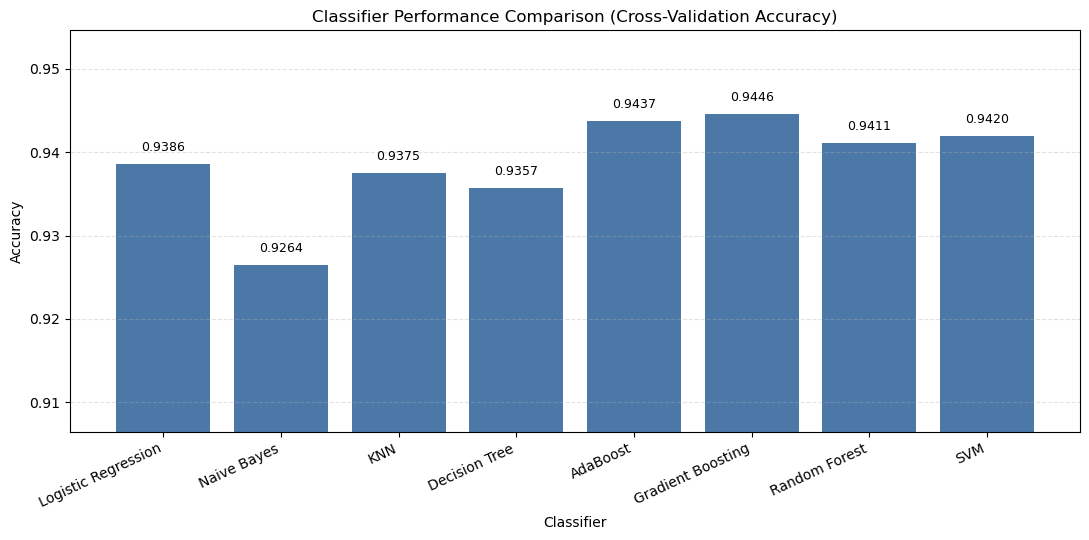

In [20]:
# Cross-validation accuracy comparison across all classifiers.
cvResultsDf = pd.DataFrame({
    "Classifier": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "Decision Tree",
        "AdaBoost",
        "Gradient Boosting",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        logRAvgAccuracy,
        nbAvgAccuracy,
        knnBestCvAccuracy,
        decisionTreeBestCvAccuracy,
        adaBoostBestCvAccuracy,
        gradientBoostBestCvAccuracy,
        randomForestBestCvAccuracy,
        svmBestCvAccuracy
    ]
})

plt.figure(figsize=(11, 5.5))
ax = plt.gca()
ax.bar(cvResultsDf["Classifier"], cvResultsDf["Accuracy"], color="#4c78a8")
ax.set_title("Classifier Performance Comparison (Cross-Validation Accuracy)")
ax.set_xlabel("Classifier")
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0.0, cvResultsDf["Accuracy"].min() - 0.02), cvResultsDf["Accuracy"].max() + 0.01)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=25, ha="right")
add_value_labels(ax)
plt.tight_layout()
plt.show()


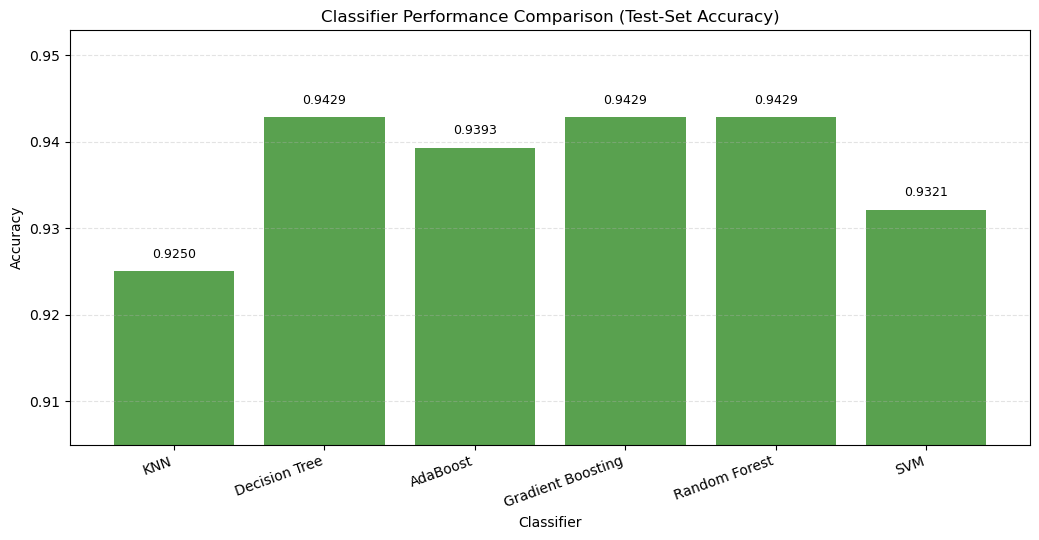

In [21]:
# Held-out test accuracy comparison for the tuned Part 2 classifiers.
testResultsDf = pd.DataFrame({
    "Classifier": [
        "KNN",
        "Decision Tree",
        "AdaBoost",
        "Gradient Boosting",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        knnTestAccuracy,
        decisionTreeTestAccuracy,
        adaBoostTestAccuracy,
        gradientBoostTestAccuracy,
        randomForestTestAccuracy,
        svmTestAccuracy
    ]
})

plt.figure(figsize=(10.5, 5.5))
ax = plt.gca()
ax.bar(testResultsDf["Classifier"], testResultsDf["Accuracy"], color="#59a14f")
ax.set_title("Classifier Performance Comparison (Test-Set Accuracy)")
ax.set_xlabel("Classifier")
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0.0, testResultsDf["Accuracy"].min() - 0.02), testResultsDf["Accuracy"].max() + 0.01)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=20, ha="right")
add_value_labels(ax)
plt.tight_layout()
plt.show()


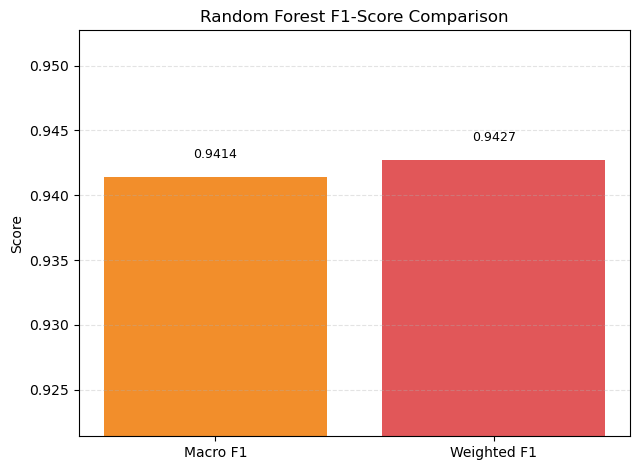

In [22]:
# Random Forest F1-score comparison, if the required metrics are available.
if "randomForestMacroF1" in globals() and "randomForestWeightedF1" in globals():
    rfF1Df = pd.DataFrame({
        "Metric": ["Macro F1", "Weighted F1"],
        "Score": [randomForestMacroF1, randomForestWeightedF1]
    })

    plt.figure(figsize=(6.5, 4.8))
    ax = plt.gca()
    ax.bar(rfF1Df["Metric"], rfF1Df["Score"], color=["#f28e2b", "#e15759"])
    ax.set_title("Random Forest F1-Score Comparison")
    ax.set_ylabel("Score")
    ax.set_ylim(max(0.0, rfF1Df["Score"].min() - 0.02), rfF1Df["Score"].max() + 0.01)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    add_value_labels(ax)
    plt.tight_layout()
    plt.show()
else:
    # Skip gracefully if these Random Forest F1 metrics are unavailable in another notebook version.
    pass


In this comparison, tuned tree-based and boosting methods achieve the strongest test accuracy, while KNN and SVM are slightly lower on the same split. Cross-validation and test-set values are broadly consistent, indicating stable generalization under the selected preprocessing and evaluation protocol.


## **3. Reflection and Discussion**


### Performance Ranking Summary

| Ranking View | Order |
|---|---|
| Cross-validation accuracy | Gradient Boosting > AdaBoost > SVM > Random Forest > Logistic Regression > KNN > Decision Tree > Naive Bayes |
| Held-out test accuracy (Part 2) | Decision Tree = Gradient Boosting = Random Forest > AdaBoost > SVM > KNN |

This table summarizes the relative ranking of the reported model performances using the notebook's printed results.


### Reflection and Discussion

1. **Overall pattern reflected by Part 1 and Part 2**
   - **Part 1** serves as a baseline comparison under 10-fold stratified cross-validation without hyperparameter tuning. The strong performance of **Logistic Regression**, together with the smaller gap to **Naive Bayes**, suggests that the two rice classes are already reasonably well separated after preprocessing.
   - **Part 2** then examines whether more flexible models and hyperparameter tuning can further improve generalisation under a train/test split with `GridSearchCV` applied only to the training set. The results show that tuning and model complexity do lead to some improvement, but the gain is limited rather than dramatic.
   - Taken together, these findings indicate that preprocessing contributes substantially to making the task easier. The stronger models refine performance, but they do not fundamentally change the outcome, which implies that the dataset is not highly complex once missing values and scaling are handled appropriately.

2. **Comparison of models from the algorithm-design perspective**
   - **Linear / probabilistic models:** **Logistic Regression** remains highly competitive because a linear decision boundary appears sufficient to capture much of the class structure in the processed feature space. Its strengths include simplicity, interpretability, and stable optimisation. By contrast, **Naive Bayes** is efficient and easy to apply, but its conditional independence assumption is restrictive for geometric features that are likely to be correlated, which helps explain its relatively weaker performance.
   - **Distance-based and single-tree models:** **KNN** can capture local structure without assuming a fixed global form, but it is sensitive to feature scaling, neighbourhood choice, and local sample arrangement, which may reduce stability. **Decision Tree** is attractive because it is interpretable and can represent nonlinear relationships directly through recursive splits; however, a single tree may also have relatively high variance and can be sensitive to small changes in the training data.
   - **Ensemble and nonlinear models:** **AdaBoost** and **Gradient Boosting** improve performance by sequentially correcting earlier mistakes, **Random Forest** improves robustness by aggregating multiple decorrelated trees, and **SVM** uses the RBF kernel to model flexible nonlinear decision boundaries. These models therefore have greater capacity to capture complex feature interactions. However, their advantage is still modest, which is consistent with a dataset that is already fairly well structured after preprocessing.

3. **What tuning, ensemble methods, and the leakage fix reveal**
   - **Impact of hyperparameter tuning:** Hyperparameter tuning is beneficial, but the improvement is modest. This suggests that  the strong baseline already captures most of the available signal. The fact that several selected hyperparameters lie on the boundaries of the search grids also suggests that the tested ranges were reasonable for the assignment, although they may not fully cover the broader optimum region. Given the limited improvements in accruacy, this report suggests leaving the searching grid as it is.
   -  **Why some ensemble-based models are strong candidates on this dataset:** The results suggest that ensemble-based methods are among the most suitable options for this dataset, particularly because they combine multiple learners to improve robustness and capture more complex structure. In particular, **Random Forest** reduces variance through aggregation, while **Gradient Boosting** improves performance by sequentially correcting earlier errors. Their strong results therefore align with their algorithmic design. However, the improvement over simpler baselines remains limited, which suggests that the dataset is already fairly well structured after preprocessing and does not require very high model complexity to achieve strong performance.
   - **Data leakage issue and resolution:** A potential preprocessing leakage issue was identified because fitting imputation and scaling on the full dataset before cross-validation or before the train/test split can allow information from validation or test data to influence preprocessing parameters. This was corrected by keeping the separate preprocessing block only for the assignment-required printed preview, while moving `SimpleImputer` and `MinMaxScaler` into `Pipeline` for both Part 1 and Part 2 evaluation. As a result, preprocessing is fitted only on the training folds or training split, making the evaluation more rigorous and the reported results more methodologically sound.

## **4. AI Acknowledgment**

AI-based tools were used to support editing, wording refinement, and code review during preparation of this notebook. 
